Columns: Index(['start_node', 'end_node', 'road_distance',
       'euclidean_distance_to_goal'],
      dtype='str')

--- A* RESULT ---
Path: ['L7', 'L4']
Distance: 14.21

--- ML OUTPUT ---
Predicted ETA: 35.77
KNN Time: 30.0
Status: LATE
Route Decision: ALTERNATE


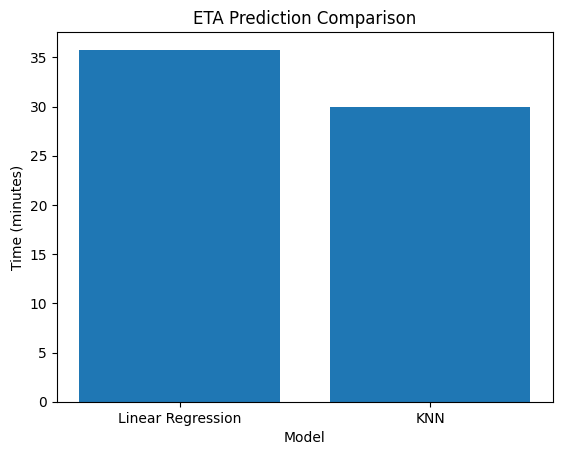

In [4]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import heapq
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier


# LOAD DATASET
data = pd.read_csv("logistics_route_dataset-1.csv")

# CLEAN COLUMN NAMES (IMPORTANT)
data.columns = data.columns.str.strip().str.lower().str.replace(" ", "_")

print("Columns:", data.columns)


# CHECK REQUIRED COLUMNS
required_cols = ['start_node', 'end_node', 'road_distance']

for col in required_cols:
    if col not in data.columns:
        raise Exception(f"Column '{col}' not found in dataset")

graph = {}

for _, row in data.iterrows():
    start = row['start_node']
    end = row['end_node']
    dist = row['road_distance']

    if start not in graph:
        graph[start] = {}

    graph[start][end] = dist

# HEURISTIC
heuristic = {}

if 'euclidean_distance_to_goal' in data.columns:
    for _, row in data.iterrows():
        heuristic[row['start_node']] = row['euclidean_distance_to_goal']

for node in graph:
    if node not in heuristic:
        heuristic[node] = 0

def a_star(start, goal):
    open_list = []
    heapq.heappush(open_list, (0, start))

    g_cost = {node: float('inf') for node in graph}
    g_cost[start] = 0

    parent = {start: None}

    while open_list:
        _, current = heapq.heappop(open_list)

        if current == goal:
            break

        for neighbor in graph.get(current, {}):
            cost = g_cost[current] + graph[current][neighbor]

            if cost < g_cost.get(neighbor, float('inf')):
                g_cost[neighbor] = cost
                f_cost = cost + heuristic.get(neighbor, 0)
                heapq.heappush(open_list, (f_cost, neighbor))
                parent[neighbor] = current

    path = []
    node = goal

    while node in parent:
        path.append(node)
        node = parent[node]

    path.reverse()

    return path, g_cost.get(goal, float('inf'))

start_node = list(graph.keys())[0]
goal_node = list(graph.keys())[-1]

path, distance = a_star(start_node, goal_node)

print("\n--- A* RESULT ---")
print("Path:", path)
print("Distance:", distance)


#  ML DATA 
X = np.array([
    [5, 0, 3],
    [10, 1, 5],
    [15, 2, 6],
    [8, 1, 4],
    [12, 2, 5]
])

y_time = np.array([15, 25, 35, 20, 30])
y_delay = np.array([0, 0, 1, 0, 1])


# TRAIN MODELS
lr_model = LinearRegression().fit(X, y_time)
knn_model = KNeighborsRegressor(n_neighbors=3).fit(X[:, :2], y_time)
log_model = LogisticRegression().fit(X[:, :2], y_delay)
tree_model = DecisionTreeClassifier().fit(X[:, :2], y_delay)

# ML PREDICTIONS
stops = len(path)
traffic = 1  # assumed

eta = lr_model.predict([[distance, traffic, stops]])
knn_time = knn_model.predict([[distance, traffic]])
delay = log_model.predict([[distance, traffic]])
decision = tree_model.predict([[distance, traffic]])

print("\n--- ML OUTPUT ---")
print("Predicted ETA:", round(eta[0], 2))
print("KNN Time:", round(knn_time[0], 2))
print("Status:", "LATE" if delay[0] == 1 else "ON TIME")
print("Route Decision:", "ALTERNATE" if decision[0] == 1 else "NORMAL")

models = ['Linear Regression', 'KNN']
times = [eta[0], knn_time[0]]

#ETA COMPARISON

plt.figure()
plt.bar(models, times)
plt.title("ETA Prediction Comparison")
plt.xlabel("Model")
plt.ylabel("Time (minutes)")

plt.show()